# 03 — Real-Time Squat Counter and ML Posture Classifier

This notebook integrates the two project pipelines:

- MediaPipe/OpenCV extracts the **same 12 feature columns** used to train Notebook 02,
- the saved `.joblib` pipeline from Notebook 02 classifies every valid live frame,
- a separate state machine uses the knee angle to count completed repetitions,
- both ML predictions and counter state are displayed and exported.

All angular features are expressed in **degrees**. Normalized displacement features use MediaPipe image coordinates and are divided by shoulder width where indicated. The model schema is read from `outputs/model_metadata.json`; the live feature dictionary is validated by feature **name** and then reordered to the exact metadata order before inference. Missing, duplicate, or unexpected features still stop execution, while harmless ordering differences do not.

The counter thresholds remain project baselines rather than medical or professional coaching advice.


Raw model classes are converted through `CLASS_LABELS` and `POSTURE_MESSAGES`. Because Notebook 02 stores only numeric class IDs, the mapping below is deliberately explicit and must match the dataset's actual label definitions; unknown classes are shown with a clear fallback rather than an unexplained integer.


In [24]:
from pathlib import Path
from collections import deque
import json

import cv2
import joblib
import mediapipe as mp
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

PROJECT_DIR = Path.cwd()
MODEL_DIR = PROJECT_DIR / "models"
OUTPUT_DIR = PROJECT_DIR / "outputs"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

MODEL_PATH = MODEL_DIR / "squat_posture_classifier_improved.joblib"
METADATA_PATH = OUTPUT_DIR / "model_metadata.json"

print("Project directory:", PROJECT_DIR.resolve())
print("Output directory:", OUTPUT_DIR.resolve())


Project directory: C:\Users\boale\Deep Neural Engineering
Output directory: C:\Users\boale\Deep Neural Engineering\outputs


## Feature extraction shared with Notebook 02

Notebook 02 trains on the following ordered columns:

`left_knee_angle`, `right_knee_angle`, `left_hip_angle`, `right_hip_angle`, `left_ankle_angle`, `right_ankle_angle`, `spine_angle`, `torso_lean`, `left_knee_lateral`, `right_knee_lateral`, `symmetry_score`, `hip_depth`.

The extractor below returns exactly those names, order, and declared units. Notebook 02 stores the column names but not the original feature-generation formulas, so the formulas are made explicit here and should be checked against Notebook 01 (or the script that created `squat_features_augmented.csv`) before treating semantic equivalence as proven. Derived means used by the repetition counter are calculated separately and are **not** passed to the classifier.


In [25]:
TRAINING_FEATURE_COLUMNS = [
    "left_knee_angle",
    "right_knee_angle",
    "left_hip_angle",
    "right_hip_angle",
    "left_ankle_angle",
    "right_ankle_angle",
    "spine_angle",
    "torso_lean",
    "left_knee_lateral",
    "right_knee_lateral",
    "symmetry_score",
    "hip_depth",
]


def angle_2d(a, b, c):
    """Return angle ABC in degrees for 2D points a, b and c."""
    a, b, c = (np.asarray(point, dtype=float) for point in (a, b, c))
    if not all(np.all(np.isfinite(point)) for point in (a, b, c)):
        return np.nan
    ba, bc = a - b, c - b
    denominator = np.linalg.norm(ba) * np.linalg.norm(bc)
    if denominator < 1e-8:
        return np.nan
    cosine = np.clip(np.dot(ba, bc) / denominator, -1.0, 1.0)
    return float(np.degrees(np.arccos(cosine)))


def visible_point(landmarks, index, min_visibility=0.50):
    """Return one MediaPipe landmark as x/y, or NaNs if visibility is low."""
    landmark = landmarks[index]
    if getattr(landmark, "visibility", 1.0) < min_visibility:
        return np.array([np.nan, np.nan], dtype=float)
    return np.array([landmark.x, landmark.y], dtype=float)


def midpoint(a, b):
    """Return midpoint when both points are finite; otherwise NaNs."""
    if np.all(np.isfinite(a)) and np.all(np.isfinite(b)):
        return (a + b) / 2.0
    return np.array([np.nan, np.nan], dtype=float)


def safe_mean(values):
    finite = [float(value) for value in values if np.isfinite(value)]
    return float(np.mean(finite)) if finite else np.nan


def normalized_horizontal_offset(point, reference, scale):
    """Signed x displacement divided by a body-size scale."""
    if not (np.all(np.isfinite(point)) and np.all(np.isfinite(reference))):
        return np.nan
    if not np.isfinite(scale) or scale < 1e-8:
        return np.nan
    return float((point[0] - reference[0]) / scale)


def extract_training_features(landmarks, min_visibility=0.50):
    """Extract the 12 Notebook-02 training features from MediaPipe landmarks.

    Angle features are in degrees. Lateral offsets and hip depth are normalized
    MediaPipe-coordinate distances. The returned dictionary order matches the
    training schema exactly.
    """
    P = mp.solutions.pose.PoseLandmark
    point = lambda name: visible_point(landmarks, getattr(P, name).value, min_visibility)

    left_shoulder, right_shoulder = point("LEFT_SHOULDER"), point("RIGHT_SHOULDER")
    left_hip, right_hip = point("LEFT_HIP"), point("RIGHT_HIP")
    left_knee, right_knee = point("LEFT_KNEE"), point("RIGHT_KNEE")
    left_ankle, right_ankle = point("LEFT_ANKLE"), point("RIGHT_ANKLE")
    left_foot, right_foot = point("LEFT_FOOT_INDEX"), point("RIGHT_FOOT_INDEX")

    shoulder_mid = midpoint(left_shoulder, right_shoulder)
    hip_mid = midpoint(left_hip, right_hip)
    knee_mid = midpoint(left_knee, right_knee)

    shoulder_width = (
        float(np.linalg.norm(left_shoulder - right_shoulder))
        if np.all(np.isfinite(left_shoulder)) and np.all(np.isfinite(right_shoulder))
        else np.nan
    )

    left_knee_angle = angle_2d(left_hip, left_knee, left_ankle)
    right_knee_angle = angle_2d(right_hip, right_knee, right_ankle)
    left_hip_angle = angle_2d(left_shoulder, left_hip, left_knee)
    right_hip_angle = angle_2d(right_shoulder, right_hip, right_knee)
    left_ankle_angle = angle_2d(left_knee, left_ankle, left_foot)
    right_ankle_angle = angle_2d(right_knee, right_ankle, right_foot)
    spine_angle = angle_2d(shoulder_mid, hip_mid, knee_mid)

    torso_lean = np.nan
    if np.all(np.isfinite(shoulder_mid)) and np.all(np.isfinite(hip_mid)):
        torso_vector = shoulder_mid - hip_mid
        if np.linalg.norm(torso_vector) > 1e-8:
            torso_lean = angle_2d(shoulder_mid, hip_mid, hip_mid + np.array([0.0, -1.0]))

    left_knee_lateral = normalized_horizontal_offset(left_knee, left_ankle, shoulder_width)
    right_knee_lateral = normalized_horizontal_offset(right_knee, right_ankle, shoulder_width)

    symmetry_score = safe_mean([
        abs(left_knee_angle - right_knee_angle),
        abs(left_hip_angle - right_hip_angle),
        abs(left_ankle_angle - right_ankle_angle),
    ])

    hip_depth = np.nan
    if np.all(np.isfinite(hip_mid)) and np.all(np.isfinite(knee_mid)) and np.isfinite(shoulder_width) and shoulder_width > 1e-8:
        hip_depth = float((hip_mid[1] - knee_mid[1]) / shoulder_width)

    values = {
        "left_knee_angle": left_knee_angle,
        "right_knee_angle": right_knee_angle,
        "left_hip_angle": left_hip_angle,
        "right_hip_angle": right_hip_angle,
        "left_ankle_angle": left_ankle_angle,
        "right_ankle_angle": right_ankle_angle,
        "spine_angle": spine_angle,
        "torso_lean": torso_lean,
        "left_knee_lateral": left_knee_lateral,
        "right_knee_lateral": right_knee_lateral,
        "symmetry_score": symmetry_score,
        "hip_depth": hip_depth,
    }
    assert list(values) == TRAINING_FEATURE_COLUMNS
    return values


def counter_features(training_features):
    """Derive counter-only features without changing the ML input schema."""
    return {
        "mean_knee_angle": safe_mean([
            training_features["left_knee_angle"],
            training_features["right_knee_angle"],
        ]),
        "mean_hip_angle": safe_mean([
            training_features["left_hip_angle"],
            training_features["right_hip_angle"],
        ]),
    }


def mean_lower_body_visibility(landmarks):
    P = mp.solutions.pose.PoseLandmark
    indices = [
        P.LEFT_HIP.value, P.RIGHT_HIP.value,
        P.LEFT_KNEE.value, P.RIGHT_KNEE.value,
        P.LEFT_ANKLE.value, P.RIGHT_ANKLE.value,
    ]
    return float(np.mean([landmarks[index].visibility for index in indices]))


## Load and validate the Notebook 02 classifier

The full scikit-learn pipeline is loaded from disk, so Notebook 03 uses the same preprocessing and classifier fitted in Notebook 02. Metadata validation makes feature incompatibilities explicit.


In [26]:
REQUIRE_CLASSIFIER = True

if not MODEL_PATH.exists() or not METADATA_PATH.exists():
    message = (
        "Run Notebook 02 first. Expected model and metadata at:\n"
        f"  {MODEL_PATH.resolve()}\n  {METADATA_PATH.resolve()}"
    )
    if REQUIRE_CLASSIFIER:
        raise FileNotFoundError(message)
    print(message)
    posture_model = None
    model_metadata = {"feature_columns": TRAINING_FEATURE_COLUMNS, "classes": []}
else:
    posture_model = joblib.load(MODEL_PATH)
    model_metadata = json.loads(METADATA_PATH.read_text(encoding="utf-8"))

    if METADATA_PATH.stat().st_mtime < MODEL_PATH.stat().st_mtime:
        warnings.warn(
            "model_metadata.json is older than the .joblib model. Re-run Notebook 02 "
            "so the model and metadata are regenerated together."
        )

expected_features = list(model_metadata.get("feature_columns", []))
live_features = list(TRAINING_FEATURE_COLUMNS)

if not expected_features:
    raise ValueError("model_metadata.json does not contain a non-empty 'feature_columns' list.")
if len(expected_features) != len(set(expected_features)):
    raise ValueError("Notebook 02 metadata contains duplicate feature names.")
if len(live_features) != len(set(live_features)):
    raise ValueError("Notebook 03 contains duplicate feature names.")

missing_features = sorted(set(expected_features) - set(live_features))
unexpected_features = sorted(set(live_features) - set(expected_features))
if missing_features or unexpected_features:
    raise ValueError(
        "Notebook 03 feature names do not match Notebook 02 metadata.\n"
        f"Missing in Notebook 03: {missing_features}\n"
        f"Unexpected in Notebook 03: {unexpected_features}"
    )

if expected_features != live_features:
    warnings.warn(
        "Feature names match, but their order differs. Notebook 03 will reorder each "
        "model input to the exact order stored in model_metadata.json."
    )

# IMPORTANT: replace these descriptions with the actual semantic definitions used
# when labels 0-5 were created. Notebook 02 currently saves IDs, not their meanings.
CLASS_LABELS = {
    "0": "Posture class 0",
    "1": "Posture class 1",
    "2": "Posture class 2",
    "3": "Posture class 3",
    "4": "Posture class 4",
    "5": "Posture class 5",
}

POSTURE_MESSAGES = {
    "0": "Replace with feedback for class 0",
    "1": "Replace with feedback for class 1",
    "2": "Replace with feedback for class 2",
    "3": "Replace with feedback for class 3",
    "4": "Replace with feedback for class 4",
    "5": "Replace with feedback for class 5",
}

metadata_classes = [str(value) for value in model_metadata.get("classes", [])]
unmapped_classes = sorted(set(metadata_classes) - set(CLASS_LABELS))
if unmapped_classes:
    warnings.warn(
        "No human-readable CLASS_LABELS entry exists for model classes: "
        f"{unmapped_classes}. They will use an explicit fallback label."
    )

print("Classifier:", model_metadata.get("best_model", type(posture_model).__name__))
print("Classes:", metadata_classes)
print("Validated feature columns:", len(expected_features))


def class_label(predicted_class):
    """Convert a model class ID to display text without hiding unmapped values."""
    key = str(predicted_class)
    return CLASS_LABELS.get(key, f"Unmapped posture class {key}")


def posture_message(predicted_class):
    """Return class-specific user feedback, with a safe unmapped fallback."""
    key = str(predicted_class)
    return POSTURE_MESSAGES.get(key, "No class-specific feedback configured")


def predict_posture(training_features):
    """Return predicted class, display label, and confidence for one frame."""
    if posture_model is None:
        return "unavailable", "Classifier unavailable", np.nan

    missing_values = [name for name in expected_features if name not in training_features]
    extra_values = [name for name in training_features if name not in expected_features]
    if missing_values or extra_values:
        raise ValueError(
            f"Per-frame feature mismatch. Missing: {missing_values}; unexpected: {extra_values}"
        )

    # Reordering here makes a harmless dictionary/list order change safe.
    model_input = pd.DataFrame(
        [[training_features[name] for name in expected_features]],
        columns=expected_features,
    )
    prediction = str(posture_model.predict(model_input)[0])

    confidence = np.nan
    if hasattr(posture_model, "predict_proba"):
        confidence = float(np.max(posture_model.predict_proba(model_input)[0]))

    return prediction, class_label(prediction), confidence


Classifier: hist_gradient_boosting
Classes: ['0', '1', '2', '3', '4', '5']
Validated feature columns: 12


## State-based repetition counter

A repetition is counted only after the smoothed knee angle remains below the down threshold for several frames and subsequently returns above the standing threshold. This prevents repeated counts while the user remains at the bottom.

In [27]:
class SquatCounter:
    def __init__(
        self,
        down_threshold=105,
        up_threshold=165,
        min_down_frames=3,
        smoothing_window=5,
    ):
        if down_threshold >= up_threshold:
            raise ValueError("down_threshold must be smaller than up_threshold.")
        if min_down_frames < 1:
            raise ValueError("min_down_frames must be at least 1.")
        if smoothing_window < 1:
            raise ValueError("smoothing_window must be at least 1.")

        self.down_threshold = float(down_threshold)
        self.up_threshold = float(up_threshold)
        self.min_down_frames = int(min_down_frames)
        self.history = deque(maxlen=int(smoothing_window))

        self.stage = "up"
        self.down_frames = 0
        self.reps = 0

    def update(self, knee_angle):
        """Process one angle and return repetitions, stage and smoothed angle."""
        if knee_angle is None or not np.isfinite(knee_angle):
            return self.reps, self.stage, np.nan

        knee_angle = float(knee_angle)
        if not 0 <= knee_angle <= 180:
            raise ValueError("knee_angle must be between 0 and 180 degrees.")

        self.history.append(knee_angle)
        smoothed = float(np.median(self.history))

        if smoothed <= self.down_threshold:
            self.down_frames += 1
            if self.down_frames >= self.min_down_frames:
                self.stage = "down"

        elif smoothed >= self.up_threshold:
            if self.stage == "down":
                self.reps += 1
            self.stage = "up"
            self.down_frames = 0

        return self.reps, self.stage, smoothed

    def reset(self):
        """Reset all repetition-counter state."""
        self.history.clear()
        self.stage = "up"
        self.down_frames = 0
        self.reps = 0

## Unit tests

These tests validate completed repetitions, incomplete repetitions, prolonged bottom holds, missing measurements, reset behaviour and invalid input. A smoothing window of one is used in most tests so each sequence has an unambiguous expected result.

In [28]:
def process_angles(counter, angles):
    for angle in angles:
        counter.update(angle)
    return counter.reps


def test_complete_squat():
    counter = SquatCounter(min_down_frames=3, smoothing_window=1)
    angles = [170, 165, 145, 120, 100, 95, 90, 115, 140, 165, 170]
    assert process_angles(counter, angles) == 1


def test_two_complete_squats():
    counter = SquatCounter(min_down_frames=3, smoothing_window=1)
    angles = [
        170, 140, 100, 95, 90, 130, 165,
        170, 145, 98, 93, 88, 135, 168,
    ]
    assert process_angles(counter, angles) == 2


def test_incomplete_squat():
    counter = SquatCounter(min_down_frames=3, smoothing_window=1)
    angles = [170, 150, 135, 120, 115, 130, 150, 170]
    assert process_angles(counter, angles) == 0


def test_bottom_not_held_long_enough():
    counter = SquatCounter(min_down_frames=3, smoothing_window=1)
    angles = [170, 140, 100, 95, 130, 165]
    assert process_angles(counter, angles) == 0


def test_bottom_hold_counts_once():
    counter = SquatCounter(min_down_frames=3, smoothing_window=1)
    angles = [170, 140, 100, 95, 90, 92, 94, 96, 120, 145, 165, 170]
    assert process_angles(counter, angles) == 1


def test_standing_does_not_count():
    counter = SquatCounter(smoothing_window=1)
    assert process_angles(counter, [170, 168, 172, 166, 175, 170]) == 0


def test_missing_measurements_are_ignored():
    counter = SquatCounter(min_down_frames=3, smoothing_window=1)
    angles = [170, 140, 100, 95, np.nan, None, 90, 130, 165]
    assert process_angles(counter, angles) == 1


def test_reset():
    counter = SquatCounter(min_down_frames=3, smoothing_window=1)
    process_angles(counter, [170, 140, 100, 95, 90, 130, 165])
    assert counter.reps == 1

    counter.reset()
    assert counter.reps == 0
    assert counter.stage == "up"
    assert counter.down_frames == 0
    assert len(counter.history) == 0


def test_invalid_angle():
    counter = SquatCounter()
    try:
        counter.update(200)
    except ValueError:
        return
    raise AssertionError("An angle above 180 degrees should raise ValueError.")


counter_tests = [
    test_complete_squat,
    test_two_complete_squats,
    test_incomplete_squat,
    test_bottom_not_held_long_enough,
    test_bottom_hold_counts_once,
    test_standing_does_not_count,
    test_missing_measurements_are_ignored,
    test_reset,
    test_invalid_angle,
]

passed = 0
for test in counter_tests:
    try:
        test()
        print(f"PASS: {test.__name__}")
        passed += 1
    except Exception as error:
        print(f"FAIL: {test.__name__}")
        print(f"      {type(error).__name__}: {error}")

print(f"\nPassed: {passed}/{len(counter_tests)}")
assert passed == len(counter_tests), "Some repetition-counter tests failed."

PASS: test_complete_squat
PASS: test_two_complete_squats
PASS: test_incomplete_squat
PASS: test_bottom_not_held_long_enough
PASS: test_bottom_hold_counts_once
PASS: test_standing_does_not_count
PASS: test_missing_measurements_are_ignored
PASS: test_reset
PASS: test_invalid_angle

Passed: 9/9


In [29]:
def feedback_from_features(training_features, stage, predicted_class, predicted_label, confidence):
    """Combine readable ML output with cautious rule-based movement cues."""
    messages = [f"ML posture: {predicted_label}"]
    class_feedback = posture_message(predicted_class)
    if class_feedback:
        messages.append(class_feedback)

    knee_angle = counter_features(training_features)["mean_knee_angle"]
    torso_lean = training_features["torso_lean"]

    if np.isfinite(confidence):
        messages[0] += f" ({confidence:.0%})"

    if np.isfinite(knee_angle) and stage != "down" and 105 < knee_angle < 140:
        messages.append("Continue lowering with control")
    elif stage == "down":
        messages.append("Bottom position detected")

    if np.isfinite(torso_lean) and torso_lean > 45:
        messages.append("Reduce forward torso lean")

    return messages


## Run on webcam or saved video

Set `SOURCE = 0` for the default webcam, or provide a saved video path such as `SOURCE = "sample_data/sample_squat.mp4"`. A saved video is preferable for reproducible project demonstrations.

Set `DISPLAY_WINDOW = False` when running in a notebook environment without desktop window support. Press **q** to stop when the OpenCV window is enabled.

In [13]:
SOURCE = 0
SAVE_OUTPUT_VIDEO = False
DISPLAY_WINDOW = True

OUTPUT_VIDEO = OUTPUT_DIR / "annotated_squat.mp4"
OUTPUT_CSV = OUTPUT_DIR / "squat_session_features.csv"

MIN_LANDMARK_VISIBILITY = 0.50
MIN_PREDICTION_CONFIDENCE = 0.60

# Replace this with the class ID used for correct posture
# in the training data from Notebook 02.
GOOD_POSTURE_CLASSES = {0}


def valid_feature(features, name):
    """Return a numeric feature value or NaN when unavailable."""
    value = features.get(name, np.nan)

    try:
        value = float(value)
    except (TypeError, ValueError):
        return np.nan

    return value if np.isfinite(value) else np.nan


def generate_improvement_feedback(features):
    """
    Use the live feature values to explain which aspects of the
    squat posture should be improved.
    """
    feedback = []

    left_knee_angle = valid_feature(
        features,
        "left_knee_angle",
    )
    right_knee_angle = valid_feature(
        features,
        "right_knee_angle",
    )
    left_hip_angle = valid_feature(
        features,
        "left_hip_angle",
    )
    right_hip_angle = valid_feature(
        features,
        "right_hip_angle",
    )
    torso_angle = valid_feature(
        features,
        "torso_angle",
    )

    left_knee_valgus = valid_feature(
        features,
        "left_knee_valgus_angle",
    )
    right_knee_valgus = valid_feature(
        features,
        "right_knee_valgus_angle",
    )
    hip_drop = valid_feature(
        features,
        "hip_drop",
    )

    available_knee_angles = [
        angle
        for angle in [left_knee_angle, right_knee_angle]
        if np.isfinite(angle)
    ]

    available_hip_angles = [
        angle
        for angle in [left_hip_angle, right_hip_angle]
        if np.isfinite(angle)
    ]

    mean_knee_angle = (
        float(np.mean(available_knee_angles))
        if available_knee_angles
        else np.nan
    )

    mean_hip_angle = (
        float(np.mean(available_hip_angles))
        if available_hip_angles
        else np.nan
    )

    # Knee alignment
    if np.isfinite(left_knee_valgus) and left_knee_valgus < 165:
        feedback.append(
            "Keep your left knee aligned with your foot"
        )

    if np.isfinite(right_knee_valgus) and right_knee_valgus < 165:
        feedback.append(
            "Keep your right knee aligned with your foot"
        )

    # Torso position
    if np.isfinite(torso_angle) and torso_angle > 40:
        feedback.append(
            "Keep your chest more upright"
        )

    # Hip balance
    if np.isfinite(hip_drop) and abs(hip_drop) > 8:
        feedback.append(
            "Keep your hips level"
        )

    # Squat depth
    if np.isfinite(mean_knee_angle) and mean_knee_angle > 115:
        feedback.append(
            "Squat a little deeper"
        )

    # Left-right symmetry
    if (
        np.isfinite(left_knee_angle)
        and np.isfinite(right_knee_angle)
        and abs(left_knee_angle - right_knee_angle) > 15
    ):
        feedback.append(
            "Distribute your weight evenly"
        )

    if (
        np.isfinite(left_hip_angle)
        and np.isfinite(right_hip_angle)
        and abs(left_hip_angle - right_hip_angle) > 15
    ):
        feedback.append(
            "Keep both sides of your hips balanced"
        )

    # Hip movement
    if np.isfinite(mean_hip_angle) and mean_hip_angle > 130:
        feedback.append(
            "Push your hips farther back"
        )

    if not feedback:
        feedback.append(
            "Check your knee alignment and torso position"
        )

    # Avoid filling the screen with too many instructions.
    return feedback[:2]


def get_posture_feedback(
    predicted_class,
    confidence,
    features,
):
    """
    Convert the ML prediction into simple feedback and use the
    measured features to explain what should be improved.
    """
    if predicted_class == "unavailable":
        return ["Posture unavailable"], False

    if not np.isfinite(confidence):
        return ["Posture unavailable"], False

    if confidence < MIN_PREDICTION_CONFIDENCE:
        return ["Posture uncertain"], False

    try:
        class_id = int(predicted_class)
    except (TypeError, ValueError):
        return ["Posture unavailable"], False

    if class_id in GOOD_POSTURE_CLASSES:
        return ["Good posture"], True

    return generate_improvement_feedback(features), False


pose_module = mp.solutions.pose
drawing_module = mp.solutions.drawing_utils

counter = SquatCounter(
    down_threshold=105,
    up_threshold=165,
    min_down_frames=3,
    smoothing_window=5,
)

capture = cv2.VideoCapture(SOURCE)

if not capture.isOpened():
    raise RuntimeError(
        f"Could not open source: {SOURCE!r}"
    )

fps = capture.get(cv2.CAP_PROP_FPS)

if not np.isfinite(fps) or fps <= 0:
    fps = 30.0

writer = None
records = []

try:
    with pose_module.Pose(
        static_image_mode=False,
        model_complexity=1,
        enable_segmentation=False,
        min_detection_confidence=0.5,
        min_tracking_confidence=0.5,
    ) as pose:

        frame_index = 0

        while True:
            ok, frame = capture.read()

            if not ok:
                break

            rgb_frame = cv2.cvtColor(
                frame,
                cv2.COLOR_BGR2RGB,
            )

            result = pose.process(rgb_frame)

            features = {
                name: np.nan
                for name in TRAINING_FEATURE_COLUMNS
            }

            mean_visibility = np.nan
            confidence = np.nan
            predicted_class = "unavailable"

            reps = counter.reps
            stage = counter.stage

            posture_messages = ["Posture unavailable"]
            posture_good = False

            if result.pose_landmarks:
                landmarks = (
                    result.pose_landmarks.landmark
                )

                mean_visibility = (
                    mean_lower_body_visibility(
                        landmarks
                    )
                )

                drawing_module.draw_landmarks(
                    frame,
                    result.pose_landmarks,
                    pose_module.POSE_CONNECTIONS,
                )

                if (
                    mean_visibility
                    >= MIN_LANDMARK_VISIBILITY
                ):
                    features = extract_training_features(
                        landmarks,
                        MIN_LANDMARK_VISIBILITY,
                    )

                    derived = counter_features(features)

                    reps, stage, _ = counter.update(
                        derived["mean_knee_angle"]
                    )

                    (
                        predicted_class,
                        _,
                        confidence,
                    ) = predict_posture(features)

                    (
                        posture_messages,
                        posture_good,
                    ) = get_posture_feedback(
                        predicted_class,
                        confidence,
                        features,
                    )

                else:
                    posture_messages = [
                        "Move fully into camera view"
                    ]

            else:
                posture_messages = [
                    "Pose not detected"
                ]

            posture_text = " | ".join(
                posture_messages
            )

            records.append({
                "frame": frame_index,
                "time_seconds": frame_index / fps,
                **features,
                "mean_landmark_visibility": (
                    mean_visibility
                ),
                "predicted_class": predicted_class,
                "prediction_confidence": confidence,
                "posture_good": posture_good,
                "posture_feedback": posture_text,
                "reps": reps,
            })

            panel_height = (
                75 + 35 * len(posture_messages)
            )

            cv2.rectangle(
                frame,
                (0, 0),
                (frame.shape[1], panel_height),
                (0, 0, 0),
                -1,
            )

            cv2.putText(
                frame,
                f"Reps: {reps}",
                (15, 35),
                cv2.FONT_HERSHEY_SIMPLEX,
                0.85,
                (255, 255, 255),
                2,
            )

            for message_index, message in enumerate(
                posture_messages
            ):
                cv2.putText(
                    frame,
                    f"Feedback: {message}"
                    if message_index == 0
                    else message,
                    (
                        15,
                        70 + 35 * message_index,
                    ),
                    cv2.FONT_HERSHEY_SIMPLEX,
                    0.68,
                    (255, 255, 255),
                    2,
                )

            if SAVE_OUTPUT_VIDEO:
                if writer is None:
                    height, width = frame.shape[:2]

                    writer = cv2.VideoWriter(
                        str(OUTPUT_VIDEO),
                        cv2.VideoWriter_fourcc(
                            *"mp4v"
                        ),
                        fps,
                        (width, height),
                    )

                    if not writer.isOpened():
                        raise RuntimeError(
                            "Could not create output "
                            f"video: {OUTPUT_VIDEO}"
                        )

                writer.write(frame)

            if DISPLAY_WINDOW:
                cv2.imshow(
                    "Squat Counter and Posture Feedback",
                    frame,
                )

                if (
                    cv2.waitKey(1) & 0xFF
                    == ord("q")
                ):
                    break

            frame_index += 1

finally:
    capture.release()

    if writer is not None:
        writer.release()

    cv2.destroyAllWindows()


results_df = pd.DataFrame(records)
results_df.to_csv(
    OUTPUT_CSV,
    index=False,
)

print(
    f"Repetitions counted: {counter.reps}"
)
print(
    f"Saved measurements: "
    f"{OUTPUT_CSV.resolve()}"
)

if SAVE_OUTPUT_VIDEO:
    print(
        f"Saved annotated video: "
        f"{OUTPUT_VIDEO.resolve()}"
    )

Repetitions counted: 3
Saved measurements: C:\Users\boale\Deep Neural Engineering\outputs\squat_session_features.csv


## Session analysis

The exported table now connects both pipelines: it contains the exact 12 model-input features, the classifier output and confidence, plus the independent state-machine stage and repetition count. The chart checks the counter transitions; the class distribution summarizes the ML output.


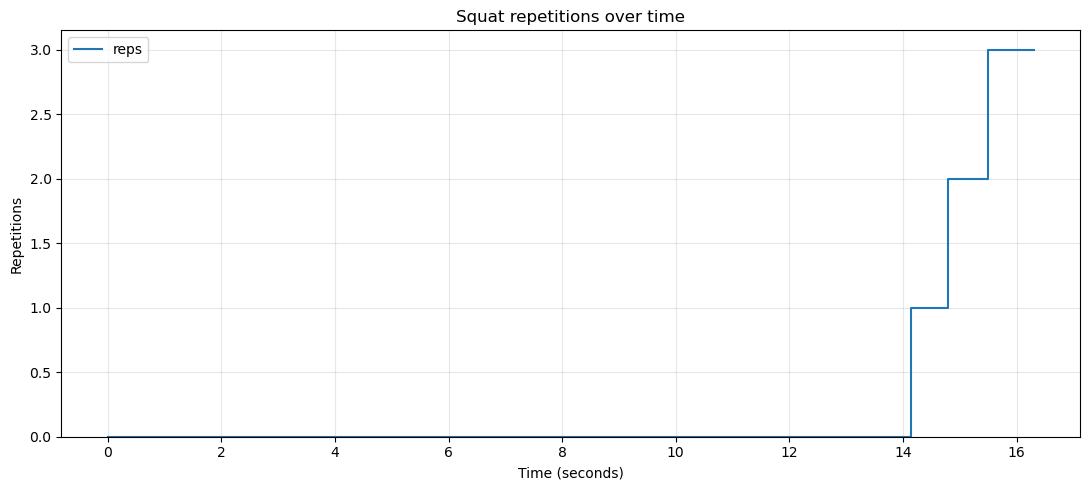

Posture feedback summary:


,frames
posture_feedback,
Move fully into camera view,287
Pose not detected,85
Squat a little deeper | Push your hips farther back,60
Check your knee alignment and torso position,30
Push your hips farther back,13
Squat a little deeper | Distribute your weight evenly,6
Distribute your weight evenly,3
Keep both sides of your hips balanced | Push your hips farther back,3
Keep both sides of your hips balanced,2


Posture quality summary:


,frames
posture_good,
Needs improvement,490


Last 10 processed frames:


,frame,time_seconds,predicted_class,prediction_confidence,posture_good,posture_feedback,reps
480,480,16.000000,3,0.999547,False,Push your hips farther back,3
481,481,16.033333,3,0.999789,False,Push your hips farther back,3
482,482,16.066667,3,0.999503,False,Push your hips farther back,3
483,483,16.100000,3,0.999392,False,Push your hips farther back,3
484,484,16.133333,3,0.998137,False,Keep both sides of your hips balanced | Push y...,3
485,485,16.166667,3,0.983583,False,Push your hips farther back,3
486,486,16.200000,3,0.962378,False,Keep both sides of your hips balanced,3
487,487,16.233333,3,0.854378,False,Keep both sides of your hips balanced,3
488,488,16.266667,3,0.962302,False,Keep both sides of your hips balanced | Push y...,3
489,489,16.300000,3,0.945608,False,Keep both sides of your hips balanced | Push y...,3


In [15]:
if results_df.empty:
    print("No frames were processed.")

else:
    # Plot the repetition count over time.
    ax = results_df.plot(
        x="time_seconds",
        y="reps",
        figsize=(11, 5),
        title="Squat repetitions over time",
        drawstyle="steps-post",
    )

    ax.set_xlabel("Time (seconds)")
    ax.set_ylabel("Repetitions")
    ax.set_ylim(bottom=0)
    ax.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

    # Show how often each posture-feedback message occurred.
    print("Posture feedback summary:")

    display(
        results_df["posture_feedback"]
        .value_counts(dropna=False)
        .to_frame("frames")
    )

    # Show the number of frames classified as good or needing improvement.
    print("Posture quality summary:")

    posture_summary = (
        results_df["posture_good"]
        .map({
            True: "Good posture",
            False: "Needs improvement",
        })
        .value_counts(dropna=False)
        .to_frame("frames")
    )

    display(posture_summary)

    # Display the final ten processed frames.
    columns_to_display = [
        "frame",
        "time_seconds",
        "predicted_class",
        "prediction_confidence",
        "posture_good",
        "posture_feedback",
        "reps",
    ]

    available_columns = [
        column
        for column in columns_to_display
        if column in results_df.columns
    ]

    print("Last 10 processed frames:")

    display(
        results_df[available_columns].tail(10)
    )
